In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data=pd.read_csv("Nike_Sales_Uncleaned.csv")
data.head()


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [5]:
#finding nulls
data.shape

(2500, 13)

In [6]:
data.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

In [7]:
data.drop("Order_Date" ,axis='columns',inplace=True)

In [8]:
#percent of nulls in each column
(data.isnull().sum()/data.shape[0])*100

Order_ID             0.00
Gender_Category      0.00
Product_Line         0.00
Product_Name         0.00
Size                20.40
Units_Sold          49.40
MRP                 50.16
Discount_Applied    66.72
Revenue              0.00
Sales_Channel        0.00
Region               0.00
Profit               0.00
dtype: float64

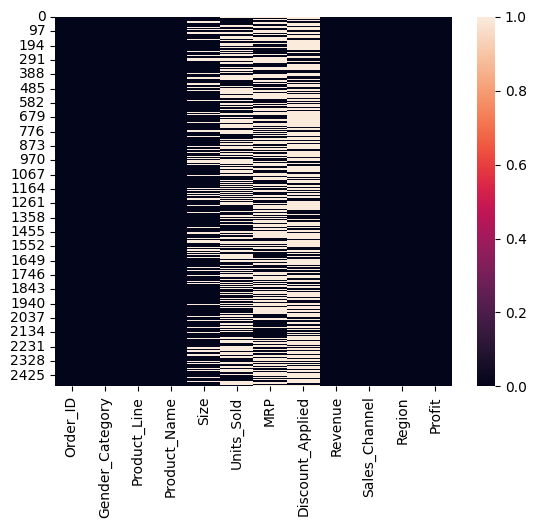

In [9]:
nulls=data.isnull()
sns.heatmap(nulls)
plt.show()

In [33]:
# filling nulls
data["Size"]=data["Size"].fillna(data["Size"].mode()[0])

In [11]:
data["Units_Sold"]=data.groupby("Product_Line")["Units_Sold"].transform(lambda x:x.fillna(x.median()))

In [18]:
data["MRP"] = data["MRP"].fillna(data.groupby("Product_Name")["MRP"].transform("median"))

In [26]:
data["Discount_Applied"]=data["Discount_Applied"].fillna(data["Discount_Applied"].median())

In [34]:
data.isnull().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

In [35]:
data.columns=data.columns.str.lower()

In [36]:
data.columns

Index(['order_id', 'gender_category', 'product_line', 'product_name', 'size',
       'units_sold', 'mrp', 'discount_applied', 'revenue', 'sales_channel',
       'region', 'profit'],
      dtype='object')

In [ ]:
#Grouping profits
label=["Lower profit","Profit","High Profit"]
data['margin_type']=pd.qcut(data["profit"],q=3,labels=label)

In [50]:
data[["profit","margin_type"]].head(10)

,profit,margin_type
0,-770.45,Lower profit
1,-112.53,Lower profit
2,3337.34,High Profit
3,3376.85,High Profit
4,187.89,Lower profit
5,1415.98,Profit
6,1802.09,Profit
7,2928.36,High Profit
8,-731.18,Lower profit
9,3929.61,High Profit
